# NBA Scoring Model by Davis Voelkel and Meyer Polanco

[Github Pages Link](https://meyerpolancoedu.github.io/)

# Project Plan
We plan to create a regression model to predict scoring of a certain player in a given future game. To do this, we will use sklearn to take features from our data to learn our label, points scored in a game. After preliminary model training, we will find the best k for k fold validation to reduce MAE and RMSE validation error. Model creation will be on a player by player basis. By  our final submission, a user will be able to input an active player, and receive a points prediction for their next game.

For our second model, we will use a n nearest neighbors classification model to try and predict which player played a game given the stats from the game. To do this, we will use z-standardization since basketball statistics are approximately normally distributed. Then, we will calculate the distances between games and train the model using k fold validation.

# Dataset
We plan to use the official NBA game stat dataset. This dataset contains game-by-game statistical information for each player in a given nba season. Some of the statistics found in this data include minutes played, points, steals, rebounds, field goal percentage, etc. With just this basic data, since advanced metrics are formulas of our basic ones, we can broadcast columns of many advanced metrics as well. Explainations of all stats used in this project can be found [here](https://www.nba.com/stats/help/glossary). This data along with the advanced metrics we derived from it will give us a lot of information which we can use to build the best estimator function described above. We plan to access this data set through the nba_api client found [here](https://github.com/swar/nba_api/tree/master). The game logs for 2003-2025 can be found in *our* github repo found [here](https://github.com/dgvoelkel/CMPS3160project). The game logs for the current season need to be continuely regenerated to account for the ongoing season. We build this contemporary data by using the `csv_generator` program that can be found in our github.

#Collaboration Plan
We plan to use a shared Google Colab notebook, and have meetings as needed, likely around once a week, on Zoom or in person. We have also created a github repository to coordinate work on additional files such as the `csv_generator` program and to store the game stat logs for prior seasons.

In [1]:
!git clone https://github.com/dgvoelkel/CMPS3160project
!pip install nba_api
%cd CMPS3160project
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from csv_generator import build_active_player_gamelog_csv
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from update_file import update_model_features
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error




Cloning into 'CMPS3160project'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 60 (delta 15), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 5.02 MiB | 4.57 MiB/s, done.
Resolving deltas: 100% (15/15), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 6.7 MB/s eta 0:00:00
/content/CMPS3160project


# ETL (Extraction, Transform, Load)

Our game stat data is stored in discrete csv files. Data from 2003-2025 is imported from out github while we generate the data for the 2025-2026 season below. This allows the data to be constantly updated every time this notebook is run! For this project, we need to concatenate these files into one dataframe so that we can preform pandas operations across all data. Once we have done this, we can also get rid of columns, like FANTASY_PTS, which we will not use in our models.

In [2]:
# Create a df for all per-season NBA game stat CSV files and combine them into a single DataFrame.

build_active_player_gamelog_csv("2025-26") # update csv for current season with latest data.

dir = "/content/CMPS3160project/nba_player_gamelogs_by_season"
frames = [] # list to append dfs to

for path in glob.glob(os.path.join(dir, "game_stats_*.csv")): # create a df for each year's stats and store in list
  df = pd.read_csv(path)
  frames.append(df)

all_years_game_stats = pd.concat(frames, ignore_index=True) # combine all the years into one dataframe
all_years_game_stats["GAME_DATE"] = pd.to_datetime(all_years_game_stats["GAME_DATE"]) # convert GAME_DATE into datetime type (used for sorting later)
all_years_game_stats["SEASON_START"] = (all_years_game_stats["SEASON"].str.split("-").str[0].astype(int)) # extract just the start year for each season

all_years_game_stats = (all_years_game_stats.sort_values(by=["GAME_DATE"]).reset_index(drop=True)) # sort game date, earliest first

all_years_game_stats.drop(columns=["FANTASY_PTS","VIDEO_AVAILABLE","SEASON_TYPE","SEASON_ID","TEAM_NAME","WL"],inplace= True) # get rid of superfluous columns
all_years_game_stats

Active players found: 530
[OK] Saved 2025-26: nba_player_gamelogs_by_season/game_stats_2025-26.csv | rows=27,397 (reg=25,923, po=1,474)


,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,MATCHUP,MIN,FGM,FGA,...,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,SEASON,SEASON_START
0,2544,LeBron James,1610612739,CLE,20300014,2003-10-29,CLE @ SAC,42,12,20,...,6,9,4,0,2,3,25,-9,2003-04,2003
1,2544,LeBron James,1610612739,CLE,20300018,2003-10-30,CLE @ PHX,41,8,17,...,12,8,1,0,7,1,21,-3,2003-04,2003
2,2544,LeBron James,1610612739,CLE,20300038,2003-11-01,CLE @ POR,39,3,12,...,4,6,2,0,2,3,8,-21,2003-04,2003
3,2544,LeBron James,1610612739,CLE,20300057,2003-11-05,CLE vs. DEN,41,3,11,...,11,7,2,3,2,1,7,-3,2003-04,2003
4,2544,LeBron James,1610612739,CLE,20300068,2003-11-07,CLE @ IND,44,8,18,...,5,3,0,0,7,2,23,-7,2003-04,2003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180898,1641709,Ausar Thompson,1610612765,DET,42500205,2026-05-13,DET vs. CLE,41,2,6,...,7,5,4,3,2,2,6,1,2025-26,2025
180899,1642450,Daniss Jenkins,1610612765,DET,42500205,2026-05-13,DET vs. CLE,41,8,17,...,2,3,1,2,0,3,19,-9,2025-26,2025
180900,201935,James Harden,1610612739,CLE,42500205,2026-05-13,CLE @ DET,43,8,21,...,8,6,1,3,6,5,30,11,2025-26,2025
180901,1627747,Caris LeVert,1610612765,DET,42500205,2026-05-13,DET vs. CLE,24,2,7,...,1,1,1,1,0,4,7,-7,2025-26,2025


For our final product, we want a search system where a user can select a player and get the prediction for the next game. However, some players have names with special characters such as Nikola Jokić. Therefore, we will use the normal_string() function from a prior project under Voelkel Informatics on Davis's GitHub.

In [3]:
from basic_stat_grab import normalize_string
all_years_game_stats["PLAYER_NAME"] = all_years_game_stats["PLAYER_NAME"].apply(normalize_string)

As we mentioned at the beginning, our dataset does not include certain advanced statistics that we wish to include in our modeling. However, we can calculate these statistics using statistics already found in our data. For example, True Shooting Percent (TS_PCT) is not found in our data. But, the data neccesary to calculate TS_PCT—Points, Field Goal Attempts, and Free Throw Attempts—are.

In [4]:
# Create new statistics in DataFrame
# True shooting percentage, effective field goal percentage, and points per shot are vital scoring efficiency metrics absent from standared box scores, but they can be derived through simple formulas!
# Three point attempt rate, 2 point attempt rate, and free throw attempt rate are important scoring tendency metrics absent from the data, but they can also be derived!
# Home games are far better environment for players, and this trend may be helpful later, so we made a boolean when the matchup contains "vs."
# Likewise, we take the opponents team tricode from matchup to make it easier to search for past matchups.

all_years_game_stats["TS_PCT"] = all_years_game_stats["PTS"] / (2 * (all_years_game_stats["FGA"] + 0.44 * all_years_game_stats["FTA"])).where(all_years_game_stats["FGA"] + all_years_game_stats["FTA"] > 0, 0.0)
all_years_game_stats["EFG_PCT"] = (all_years_game_stats["FGM"] + 0.5 * all_years_game_stats["FG3M"]) / all_years_game_stats["FGA"].where(all_years_game_stats["FGA"] > 0, 0.0)
all_years_game_stats["PPS"] = (all_years_game_stats["PTS"] / all_years_game_stats["FGA"]).where(all_years_game_stats["FGA"] > 0, 0.0)
all_years_game_stats["3PAr"] = (all_years_game_stats["FG3A"] / all_years_game_stats["FGA"]).where(all_years_game_stats["FGA"] > 0, 0.0)
all_years_game_stats["HOME"] = all_years_game_stats["MATCHUP"].str.contains("vs.", regex=False)
all_years_game_stats["OPPONENT"] = np.where(
        all_years_game_stats["MATCHUP"].str.contains("vs.", regex=False, na=False),
        all_years_game_stats["MATCHUP"].str.split("vs.").str[1].str.strip(),
        all_years_game_stats["MATCHUP"].str.split("@").str[1].str.strip()
    )
all_years_game_stats["2PAr"] = np.where(
    all_years_game_stats["FGA"] > 0,
    (all_years_game_stats["FGA"] - all_years_game_stats["FG3A"]) / all_years_game_stats["FGA"],
    0.0
)

all_years_game_stats["FTAr"] = np.where(
    all_years_game_stats["FGA"] > 0,
    all_years_game_stats["FTA"] / all_years_game_stats["FGA"],
    0.0
)

all_years_game_stats.dtypes

,0
PLAYER_ID,int64
PLAYER_NAME,object
TEAM_ID,int64
TEAM_ABBREVIATION,object
GAME_ID,int64
GAME_DATE,datetime64[ns]
MATCHUP,object
MIN,int64
FGM,int64
FGA,int64


## Missing Data Part 1
The only missing data from our dataset comes from the NaN's in the percentage based stats, including our added columns of true shooting percentage and effective field goal percentage. Looking at the formulas for all of these percentages, the metric causing these NaN's are the attempt stats, namely field goals attempted, three pointers attempted, and free throw attempts. When a player takes no shots in a game, the divide by zero causes the NaN. Defaulting these NaN's to zero is unfair for the player, because average percentages would be harmed by games where they didn't even attempt to score. Therefore, we will drop these rows, because we are not interested in making predictions on players who do not make shot attempts.

In [5]:
# Columns with at least one NaN, along with dtype and NaN count
nan_dtypes = (
    all_years_game_stats
    .isna()
    .sum()
    .reset_index(name="NaN_Count")
    .rename(columns={"index": "Column"})
)

nan_dtypes["Dtype"] = nan_dtypes["Column"].map(all_years_game_stats.dtypes)

nan_dtypes = nan_dtypes[nan_dtypes["NaN_Count"] > 0]

nan_dtypes

,Column,NaN_Count,Dtype
10,FG_PCT,5914,float64
13,FG3_PCT,37089,float64
16,FT_PCT,65276,float64
29,TS_PCT,5191,float64
30,EFG_PCT,5914,float64


In [6]:
all_years_game_stats.dropna(inplace=True)
all_years_game_stats.dtypes

,0
PLAYER_ID,int64
PLAYER_NAME,object
TEAM_ID,int64
TEAM_ABBREVIATION,object
GAME_ID,int64
GAME_DATE,datetime64[ns]
MATCHUP,object
MIN,int64
FGM,int64
FGA,int64


## Knowing past games is not enough!
Therefore we will bring in the schedule for all future games, so that we can make predictions on future games. While this is not a second dataset, it will be essential for our first model described below.

In [7]:
import pandas as pd
from nba_api.stats.endpoints import scheduleleaguev2


def get_current_nba_season(today=None):
    """
    Returns NBA season string like '2025-26'.
    NBA seasons start around October.
    """
    if today is None:
        today = pd.Timestamp.today()

    today = pd.to_datetime(today)

    # Force timezone-naive if needed
    if today.tzinfo is not None:
        today = today.tz_convert(None)

    if today.month >= 10:
        return f"{today.year}-{str(today.year + 1)[-2:]}"
    else:
        return f"{today.year - 1}-{str(today.year)[-2:]}"


def build_future_schedule_df(season=None, today=None):
    """
    Builds a dataframe of all scheduled NBA games that have not happened yet.

    Returns one row per team per game with columns:
    TEAM, OPPONENT, GAME_DATE, HOME
    """
    if today is None:
        today = pd.Timestamp.today().normalize()
    else:
        today = pd.to_datetime(today).normalize()

    # Force today to be timezone-naive
    if today.tzinfo is not None:
        today = today.tz_convert(None)

    if season is None:
        season = get_current_nba_season(today)

    schedule = scheduleleaguev2.ScheduleLeagueV2(
        league_id="00",
        season=season
    )

    games = schedule.get_data_frames()[0].copy()

    # Convert NBA API dates to timezone-naive datetime
    games["GAME_DATE"] = (
        pd.to_datetime(games["gameDateEst"], utc=True)
        .dt.tz_convert(None)
        .dt.normalize()
    )

    # Keep only games that are scheduled and not yet played
    # gameStatus:
    # 1 = scheduled
    # 2 = in progress
    # 3 = final
    future_games = games[
        (games["GAME_DATE"] >= today) &
        (games["gameStatus"] == 1)
    ].copy()

    # Home team rows
    home_rows = future_games[[
        "homeTeam_teamTricode",
        "awayTeam_teamTricode",
        "GAME_DATE"
    ]].copy()

    home_rows.columns = ["TEAM", "OPPONENT", "GAME_DATE"]
    home_rows["HOME"] = True

    # Away team rows
    away_rows = future_games[[
        "awayTeam_teamTricode",
        "homeTeam_teamTricode",
        "GAME_DATE"
    ]].copy()

    away_rows.columns = ["TEAM", "OPPONENT", "GAME_DATE"]
    away_rows["HOME"] = False

    # Combine into one dataframe
    future_schedule_df = pd.concat(
        [home_rows, away_rows],
        ignore_index=True
    )

    # Remove missing/string None teams
    future_schedule_df = future_schedule_df[
        future_schedule_df["TEAM"].notna() &
        future_schedule_df["OPPONENT"].notna() &
        (future_schedule_df["TEAM"] != "None") &
        (future_schedule_df["OPPONENT"] != "None")
    ].copy()

    future_schedule_df = (
        future_schedule_df
        .sort_values(["GAME_DATE", "TEAM"])
        .reset_index(drop=True)
    )

    return future_schedule_df

In [8]:
future_games_df = build_future_schedule_df()



display(future_games_df)

,TEAM,OPPONENT,GAME_DATE,HOME
0,CLE,DET,2026-05-15,True
1,DET,CLE,2026-05-15,False
2,MIN,SAS,2026-05-15,True
3,SAS,MIN,2026-05-15,False
4,CLE,DET,2026-05-17,False
5,DET,CLE,2026-05-17,True
6,MIN,SAS,2026-05-17,False
7,SAS,MIN,2026-05-17,True


# EDA

To start, we can simply look at the correlation that all of our stats have with points scored. This is a decent starting point to think about what stats are important to scoring. Some of the values that this produces are exactly what we would predict. Field goals made correlates very strongly to points because the vast majority of points scored are scored via field goal. However, there are some suprising values that may warrent further investigation. For example, it is somewhat suprising that rebounds seem to correlate with points at a level to true shooting percentage, a measure of a player's scoring efficiency.

In [9]:
cols = ["MIN", "FGM", "FGA", "FG_PCT", "FG3M", "FG3A", "FG3_PCT", "FTM", "FTA", "FT_PCT", "OREB", "DREB", "REB", "AST", "STL", "BLK", "TOV", "PF", "TS_PCT", "EFG_PCT", "PPS", "3PAr", "2PAr", "FTAr", "PLUS_MINUS", "PTS" ]

In [10]:

corr_with_pts = all_years_game_stats[cols].corr(numeric_only=True)["PTS"].sort_values(ascending=False).round(4)

display(corr_with_pts)

,PTS
PTS,1.0000
FGM,0.9502
FGA,0.8444
MIN,0.6197
FTM,0.5979
FTA,0.5861
FG3M,0.5782
FG3A,0.5132
FG_PCT,0.4404
TS_PCT,0.4257


Along with correlations points, we want to look at correlation with future games, not just within the same game. Because our regression model will be based on rolling averages, correlation with a current game to the next game will be more telling for our model.

In [11]:

season_stats = ( # aggregate game-level data to season-level
    all_years_game_stats.groupby(["PLAYER_ID", "SEASON_START"])[cols]
      .mean()
      .reset_index()
)

season_stats = season_stats.sort_values(["PLAYER_ID", "SEASON_START"])

season_stats["PTS_next"] = ( # create next-season points
    season_stats.groupby("PLAYER_ID")["PTS"].shift(-1)
)

season_stats = season_stats.dropna(subset=["PTS_next"]) # drop rows without next-season data to account for retired players

corr_with_future_pts = ( # compute correlations with next-season PTS
    season_stats.corr(numeric_only=True)["PTS_next"]
    .drop("PTS_next")
    .sort_values(ascending=False)
    .round(4)
)

print(corr_with_future_pts)

PTS             0.8478
FGA             0.8404
FGM             0.8274
FTM             0.7463
FTA             0.7177
TOV             0.6873
MIN             0.6661
AST             0.5520
FG3A            0.4522
DREB            0.4398
FG3M            0.4172
REB             0.3414
2PAr            0.3358
STL             0.2976
FT_PCT          0.2377
PF              0.2074
PLUS_MINUS      0.1604
FG_PCT          0.1097
BLK             0.1078
FG3_PCT         0.0945
OREB            0.0337
EFG_PCT         0.0236
TS_PCT         -0.0016
PPS            -0.1507
SEASON_START   -0.2431
PLAYER_ID      -0.2955
FTAr           -0.3211
3PAr           -0.3358
Name: PTS_next, dtype: float64


Lastly, we can compare the future correlations with the intra-game correlations. This can help distinguish between variables that merely co-move with scoring in the same game and those that have genuine predictive power for future performance, shedding light on which statistics reflect underlying skill versus short-term opportunity or noise.

Looking at the correlations, it appears we made a mistake by having the shot tendencies in the first version of the regression model. We will test other features to try and to optimize the model for low validation error as much as possible.

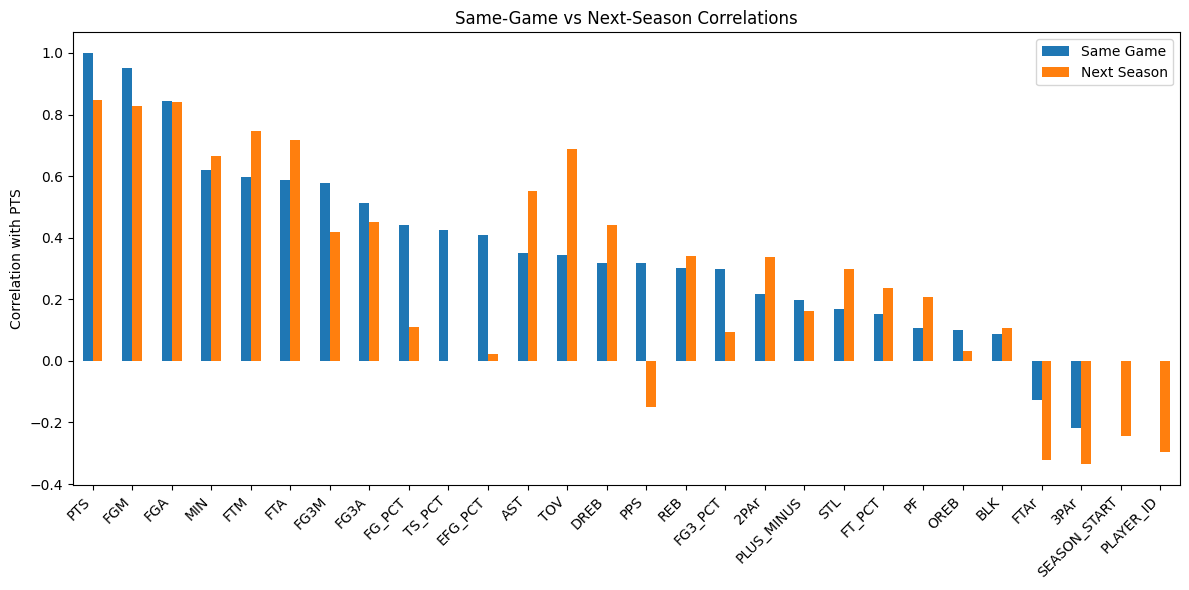

In [12]:
compare = pd.concat(
    [corr_with_pts.rename("Same Game"),
     corr_with_future_pts.rename("Next Season")],
    axis=1
)

compare.plot(kind="bar", figsize=(12,6))
plt.xticks(rotation=45, ha="right")
plt.ylabel("Correlation with PTS")
plt.title("Same-Game vs Next-Season Correlations")
plt.tight_layout()
plt.show()

It also will be helpful to have a baseline understanding of the distribution of points. One quick way to visualize this distribution is through a histogram. Interestingly enough, removing games with no shot attempts making the points distribution relatively symmetric with a slight right skew. This is a likely a result of rule changes in recent years favoring the offense, resulting in an influx of high scoring games.

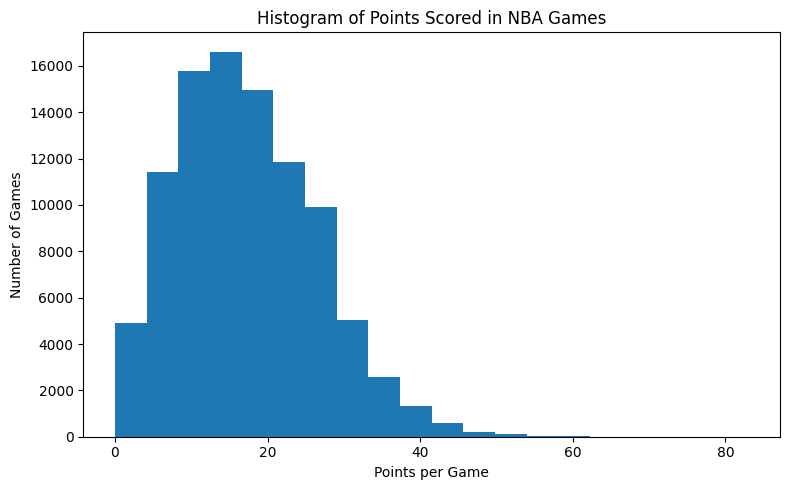

In [13]:
plt.figure(figsize=(8,5))
plt.hist(all_years_game_stats["PTS"], bins=20)

plt.xlabel("Points per Game")
plt.ylabel("Number of Games")
plt.title("Histogram of Points Scored in NBA Games")

plt.tight_layout()
plt.show()

It may be helpful to see how skewed some of our statistics are, as this provides insight into whether the distribution of each variable is symmetric or heavily influenced by extreme values, which in turn can affect the interpretation of correlations and any downstream modeling results.

Most counting statistics are somewhat positively skewed, meaning a small number of players produce exceptionally high values relative to the average. Variables such as BLK, FTAr, and FG3M show particularly strong right skew, reflecting the impact of specialists and high-usage players. In contrast, efficiency metrics like FG_PCT, TS_PCT, and EFG_PCT are more symmetric, while FT_PCT is negatively skewed because most players cluster around higher percentages with a smaller group of poor shooters forming the left tail.

In [14]:
summary = all_years_game_stats[cols].agg(["skew"]).T
display(summary)

,skew
MIN,-0.587184
FGM,0.596973
FGA,0.458670
FG_PCT,-0.059590
FG3M,1.196718
FG3A,0.943574
FG3_PCT,0.519531
FTM,1.600991
FTA,1.629947
FT_PCT,-1.334713


It may also be interesting to see how a player's points develops over their career. Because LeBron has the most data entries in this set, with 2003 and 2004 being just him, he will be a frequent testing player going forward in the project.

Text(0.5, 1.0, 'LeBron James Average Points Per Game (Seasonal)')

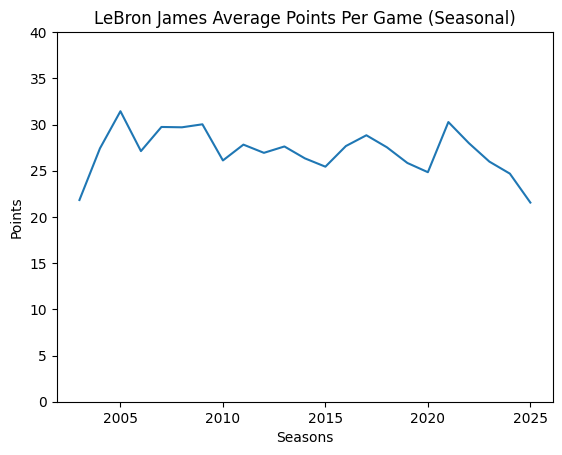

In [15]:
lebron_season_averages = all_years_game_stats.groupby(["PLAYER_NAME","SEASON_START"])["PTS"].mean()["lebron james"] # calculate average pts per game
plt.plot(lebron_season_averages)
plt.xlabel("Seasons")
plt.ylabel("Points")
plt.ylim(0,40) # force yaxis to have a better range to improve visability.
plt.title("LeBron James Average Points Per Game (Seasonal)")


#Model 1
Regression model on rolling season averages. This model takes rolling averages as features to predict points scored in a future game.

## There is an issue with our current data set!
Right now, this data is just a bunch of game stat lines. All of these metrics rely on the future game actually being played. Therefore, to make predictions on future games, you have wait for that game to be finished to get all the features, which is ridiculous. Therefore, we must process our current data, to remove this dependency. We can create a suite of statistics that summarize a players past statistics over a rolling number of games.

## Why the last 6 games?
In testing, fitting regression model with features based off the last 6 games resulted in the lowest MAE validation error. To get these rolling averages in the dataframe, we functions that calculate the rolling averages for last 6 games, last 3 matchups against the same opponent, usage rate, and home/away points and then add them as a column.

##What happens if a player doesn't have 6 past games?!
Since we use a rolling average, we take as many games as we can up to 6 to try and compensate. However, if it is a player's very first game in their career, we cannot make any predictions.

In [16]:
def get_last_6_points():
    # This function gets the average points per game in up to the last 6 games.
    all_years_game_stats["Avg_PPG_last_6"] = (
        all_years_game_stats
        .sort_values(["PLAYER_ID", "GAME_DATE"])
        .groupby("PLAYER_ID")["PTS"]
        .transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean())
    )

In [17]:
def get_matchup_average():
    # Gets the points per game average of the 3 previous matchups against the same opponent.
    sorted_df = all_years_game_stats.sort_values(
        ["PLAYER_ID", "OPPONENT", "GAME_DATE"]
    ).copy()

    all_years_game_stats["Avg_PPG_Matchup"] = (
        sorted_df
        .groupby(["PLAYER_ID", "OPPONENT"])["PTS"]
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
        .reindex(all_years_game_stats.index)
    )

In [18]:
def get_home_away_season_avg(stat_col="PTS", new_col=None):
    """
    Creates a player's season average for a stat, separated by home/away games,
    using only games before the current game.

    Example:
        get_home_away_season_avg("PTS", "HOME_AWAY_PPG")
    """

    if new_col is None:
        new_col = f"SEASON_{stat_col}_AVG_BY_HOME"

    # Sort so cumulative averages are calculated in chronological order
    sorted_df = all_years_game_stats.sort_values(
        ["SEASON", "PLAYER_ID", "HOME", "GAME_DATE"]
    ).copy()

    group_cols = ["SEASON", "PLAYER_ID", "HOME"]

    # Cumulative sum before current game
    prior_sum = (
        sorted_df
        .groupby(group_cols)[stat_col]
        .cumsum()
        - sorted_df[stat_col]
    )

    # Number of prior home/away games
    prior_count = (
        sorted_df
        .groupby(group_cols)
        .cumcount()
    )

    # Prior season average at home or away
    sorted_df[new_col] = prior_sum / prior_count

    # Put the new column back into the original dataframe order
    all_years_game_stats[new_col] = sorted_df[new_col].reindex(
        all_years_game_stats.index
    )


In [19]:
get_last_6_points()
get_matchup_average()
get_home_away_season_avg("PTS", "HOME_AWAY_PPG")

In [20]:
all_years_game_stats["Avg_MIN_last_6"] = (
    all_years_game_stats
    .sort_values(["PLAYER_ID", "GAME_DATE"])
    .groupby("PLAYER_ID")["MIN"]
    .transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean())
)

In [21]:
all_years_game_stats["Avg_FTA_last_6"] = (
    all_years_game_stats
    .sort_values(["PLAYER_ID", "GAME_DATE"])
    .groupby("PLAYER_ID")["FTA"]
    .transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean())
)

In [22]:
all_years_game_stats["Avg_FGA_last_6"] = (
    all_years_game_stats
    .sort_values(["PLAYER_ID", "GAME_DATE"])
    .groupby("PLAYER_ID")["FGA"]
    .transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean())
)

In [23]:
all_years_game_stats["Avg_FG3A_last_6"] = (
    all_years_game_stats
    .sort_values(["PLAYER_ID", "GAME_DATE"])
    .groupby("PLAYER_ID")["FG3A"]
    .transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean())
)

In [24]:
def create_player_model_df(player_name):
    id_cols = [
        "PLAYER_NAME",
        "PLAYER_ID",
        "SEASON",
        "GAME_DATE",
        "OPPONENT",
        "HOME"
    ]

    feature_cols = [
    "Avg_PPG_last_6",
    "Avg_PPG_Matchup",
    "Avg_MIN_last_6",
    "Avg_FTA_last_6",
    "Avg_FGA_last_6",
    "Avg_FG3A_last_6",
    "HOME_AWAY_PPG"
    ]

    label_col = "PTS"

    player_name = player_name.lower()

    player_df = all_years_game_stats.loc[
        all_years_game_stats["PLAYER_NAME"].str.lower() == player_name,
        id_cols + feature_cols + [label_col]
    ].copy()

    player_df = player_df.dropna(subset=feature_cols+ [label_col])

    return player_df

In [25]:
def build_player_regression_model(player_name, cv=8):
    player_df = create_player_model_df(player_name)

    feature_cols = [
        "Avg_PPG_last_6",
        "Avg_PPG_Matchup",
        "Avg_MIN_last_6",
        "Avg_FTA_last_6",
        "Avg_FGA_last_6",
        "Avg_FG3A_last_6",
        "HOME_AWAY_PPG"
    ]

    label_col = "PTS"

    X = player_df[feature_cols]
    y = player_df[label_col]

    model = make_pipeline(
        StandardScaler(),
        Lasso(alpha=0.1, max_iter=10000)
    )

    scoring = {
        "MAE": "neg_mean_absolute_error",
        "MSE": "neg_mean_squared_error"
    }

    cv = min(cv, len(player_df))

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )

    results = {
        "player_name": player_name,
        "num_features": len(feature_cols),
        "6_games": 6,
        "cv": cv,
        "train_MAE": -cv_results["train_MAE"].mean(),
        "validation_MAE": -cv_results["test_MAE"].mean(),
        "train_RMSE": np.sqrt(-cv_results["train_MSE"].mean()),
        "validation_RMSE": np.sqrt(-cv_results["test_MSE"].mean())
    }

    model.fit(X, y)

    return model, results, feature_cols

## Why 8 folds?
By testing different k's across a sample of players, k=8 performs the best. There is a concern that a player won't have 8 games in their sample, but we can deploy a lower k to allow these players to get models.

In [26]:
def build_player_regression_model(player_name, cv=8):
    player_df = create_player_model_df(player_name)

    feature_cols = [
        "Avg_PPG_last_6",
        "Avg_PPG_Matchup",
        "Avg_MIN_last_6",
        "Avg_FTA_last_6",
        "Avg_FGA_last_6",
        "Avg_FG3A_last_6",
        "HOME_AWAY_PPG"
    ]

    label_col = "PTS"

    player_df = player_df.dropna(subset=feature_cols + [label_col])

    X = player_df[feature_cols]
    y = player_df[label_col]

    model = make_pipeline(
        StandardScaler(),
        Lasso(alpha=0.1, max_iter=10000)
    )

    scoring = {
        "MAE": "neg_mean_absolute_error",
        "MSE": "neg_mean_squared_error"
    }

    cv = min(cv, len(player_df))

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )

    results = {
        "player_name": player_name,
        "cv": cv,
        "num_games": len(player_df),
        "num_features": len(feature_cols),
        "train_MAE": -cv_results["train_MAE"].mean(),
        "validation_MAE": -cv_results["test_MAE"].mean(),
        "train_RMSE": np.sqrt(-cv_results["train_MSE"].mean()),
        "validation_RMSE": np.sqrt(-cv_results["test_MSE"].mean())
    }

    model.fit(X, y)

    return model, results, feature_cols

In [27]:
lebron_model, lebron_results, feature_cols = build_player_regression_model(
    "LeBron James",
    cv=8
)
display(lebron_results)



{'player_name': 'LeBron James',
 'cv': 8,
 'num_games': 1780,
 'num_features': 7,
 'train_MAE': np.float64(5.9354678673973),
 'validation_MAE': np.float64(5.967975876638518),
 'train_RMSE': np.float64(7.532041078446721),
 'validation_RMSE': np.float64(7.5692678213077)}

## Is Lasso the best choice for our pipeline?
To check, let's iterate over many different models in sklearn and compare the validation errors and latencies.

In [28]:
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
import time

In [29]:
def compare_regression_models(player_name, feature_cols, cv=8):
    player_df = create_player_model_df(player_name)

    label_col = "PTS"
    model_cols = feature_cols + [label_col]

    player_df = player_df.dropna(subset=model_cols)

    X = player_df[feature_cols]
    y = player_df[label_col]

    models = {
        "Linear Regression": make_pipeline(
            StandardScaler(),
            LinearRegression()
        ),

        "Ridge": make_pipeline(
            StandardScaler(),
            Ridge(alpha=1.0)
        ),

        "Lasso": make_pipeline(
            StandardScaler(),
            Lasso(alpha=0.1, max_iter=10000)
        ),

        "ElasticNet": make_pipeline(
            StandardScaler(),
            ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
        ),

        "KNN": make_pipeline(
            StandardScaler(),
            KNeighborsRegressor(n_neighbors=5)
        ),

        "SVR": make_pipeline(
            StandardScaler(),
            SVR(kernel="rbf", C=1.0, epsilon=0.2)
        ),

        "Random Forest": RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ),

        "Gradient Boosting": GradientBoostingRegressor(
            random_state=42
        )
    }

    scoring = {
        "MAE": "neg_mean_absolute_error",
        "MSE": "neg_mean_squared_error",
        "R2": "r2"
    }

    results = []

    for model_name, model in models.items():
        try:
            start_time = time.perf_counter()

            cv_results = cross_validate(
                model,
                X,
                y,
                cv=cv,
                scoring=scoring,
                return_train_score=True
            )

            end_time = time.perf_counter()
            latency_seconds = end_time - start_time

            results.append({
                "Model": model_name,
                "Train_MAE": -cv_results["train_MAE"].mean(),
                "Validation_MAE": -cv_results["test_MAE"].mean(),
                "Validation_MSE": -cv_results["test_MSE"].mean(),
                "Validation_R2": cv_results["test_R2"].mean(),
                "Latency_Seconds": latency_seconds
            })

        except Exception as e:
            print(f"Skipping {model_name}: {e}")

    results_df = pd.DataFrame(results).sort_values("Validation_MAE")

    return results_df

In [30]:
feature_cols = [
    "Avg_PPG_last_6",
    "Avg_PPG_Matchup",
    "Avg_MIN_last_6",
    "Avg_FTA_last_6",
    "Avg_FGA_last_6",
    "Avg_FG3A_last_6",
    "HOME_AWAY_PPG"
]

lebron_model_comparison = compare_regression_models(
    player_name="LeBron James",
    feature_cols=feature_cols,
    cv=8
)
lebron_model_comparison["Latency_Seconds"] = lebron_model_comparison["Latency_Seconds"].round(4)
display(lebron_model_comparison)

,Model,Train_MAE,Validation_MAE,Validation_MSE,Validation_R2,Latency_Seconds
2,Lasso,5.935468,5.967976,57.293815,0.010765,0.0703
3,ElasticNet,5.934252,5.969819,57.328713,0.010293,0.0814
1,Ridge,5.930464,5.973633,57.428867,0.008905,0.0804
0,Linear Regression,5.930453,5.973669,57.429710,0.008892,0.1106
5,SVR,5.769360,6.069848,59.205642,-0.020044,1.2843
7,Gradient Boosting,5.266755,6.201235,61.932922,-0.067677,1.9417
6,Random Forest,2.288078,6.333065,63.695623,-0.097813,20.4204
4,KNN,5.309342,6.768512,71.431744,-0.237242,0.2075


Based on these results, Lasso gives us the lowest validation error, best r2 score, and lowest latency. Therefore, it will be the model we will use for both of our models!

## Now for our final product we want to make predictions on future games not in the data set!
Therefore, we must revamp some of our earlier helper functions to add new rows temporarily to the dataset, imputing missing data with the rolling average from the last played game if we make predictions for multiple games in the future.

In [31]:
def get_player_games(player_name, stats_df=all_years_game_stats):
    player_name = player_name.lower()

    player_games = (
        stats_df.loc[stats_df["PLAYER_NAME"].str.lower() == player_name]
        .sort_values("GAME_DATE")
        .copy()
    )

    if player_games.empty:
        raise ValueError(f"No games found for player: {player_name}")

    return player_games

In [32]:
def get_player_game_on_date(
    player_name,
    game_date,
    stats_df=all_years_game_stats,
    future_games_df=None
):
    game_date = pd.to_datetime(game_date).normalize()

    player_games = get_player_games(player_name, stats_df)

    # ---------------------------------
    # 1. First try historical game lookup
    # ---------------------------------
    historical_game = player_games.loc[
        player_games["GAME_DATE"].dt.normalize() == game_date
    ]

    if not historical_game.empty:
        game = historical_game.iloc[0].copy()
        game["IS_FUTURE"] = False
        return game

    # ---------------------------------
    # 2. If no historical game, try future schedule
    # ---------------------------------
    if future_games_df is None:
        future_games_df = build_future_schedule_df(today=pd.Timestamp.today())

    latest_game = player_games.sort_values("GAME_DATE").iloc[-1]
    player_team = latest_game["TEAM_ABBREVIATION"]

    future_match = future_games_df.loc[
        (future_games_df["TEAM"].str.upper() == str(player_team).upper()) &
        (future_games_df["GAME_DATE"].dt.normalize() == game_date)
    ]

    if future_match.empty:
        return None

    future_game = future_match.iloc[0]

    return pd.Series({
        "PLAYER_NAME": latest_game["PLAYER_NAME"],
        "PLAYER_ID": latest_game["PLAYER_ID"],
        "TEAM_ABBREVIATION": player_team,
        "GAME_DATE": future_game["GAME_DATE"],
        "OPPONENT": future_game["OPPONENT"],
        "HOME": future_game["HOME"],
        "SEASON": latest_game["SEASON"],
        "PTS": np.nan,
        "IS_FUTURE": True
    })

In [33]:
def get_prior_player_games(player_name, game_date, stats_df=all_years_game_stats):
    game_date = pd.to_datetime(game_date)

    player_games = get_player_games(player_name, stats_df)

    prior_games = player_games.loc[
        player_games["GAME_DATE"] < game_date
    ].sort_values("GAME_DATE")

    if prior_games.empty:
        raise ValueError(
            f"No prior games found for {player_name} before {game_date.date()}."
        )

    return prior_games

In [34]:
def get_previous_feature_value(prior_games, feature_col):
    """
    Gets the most recent non-missing value of a feature from the player's previous games.
    Used as an imputation fallback.
    """
    if feature_col not in prior_games.columns:
        return np.nan

    previous_values = prior_games[feature_col].dropna()

    if previous_values.empty:
        return np.nan

    return previous_values.iloc[-1]

##Missing Data Part 2
If the user wants to make a prediction on a game that is scheduled after another player game, there will obviously be NaN values for that previous unplayed game. Therefore, we recursively impute missing values with the last seen rolling averages from played game, which effectively treats a further future game as if its the soonest future game.

In [35]:
def impute_with_previous_game_value(value, prior_games, feature_col):
    """
    If a newly calculated feature is missing, use the previous available
    value of that same feature from the player's prior games.
    """
    if pd.notna(value):
        return value

    previous_value = get_previous_feature_value(prior_games, feature_col)

    if pd.notna(previous_value):
        return previous_value

    raise ValueError(
        f"Could not calculate or impute {feature_col}. "
        "There may not be enough prior games."
    )

In [36]:
def get_future_last_6_points(player_name, game_date, stats_df=all_years_game_stats):
    player_games = get_player_games_before_date(
        player_name=player_name,
        game_date=game_date,
        stats_df=stats_df
    )

    return player_games["PTS"].tail(6).mean()

In [37]:
def get_future_last_6_volume_features(player_name, game_date, stats_df=all_years_game_stats):
    player_games = get_player_games_before_date(
        player_name=player_name,
        game_date=game_date,
        stats_df=stats_df
    )

    recent_games = player_games.tail(6)

    return {
        "Avg_MIN_last_6": recent_games["MIN"].mean(),
        "Avg_FTA_last_6": recent_games["FTA"].mean(),
        "Avg_FGA_last_6": recent_games["FGA"].mean(),
        "Avg_FG3A_last_6": recent_games["FG3A"].mean()
    }

In [38]:
def get_future_home_away_ppg(player_name, game_date, home, stats_df=all_years_game_stats):
    player_games = get_player_games_before_date(
        player_name=player_name,
        game_date=game_date,
        stats_df=stats_df
    )

    latest_season = player_games["SEASON"].iloc[-1]

    matching_games = player_games.loc[
        (player_games["SEASON"] == latest_season)
        & (player_games["HOME"] == home)
    ]

    if matching_games.empty:
        season_games = player_games.loc[player_games["SEASON"] == latest_season]
        return season_games["PTS"].mean()

    return matching_games["PTS"].mean()

In [39]:
def get_future_matchup_average(player_name, game_date, opponent, stats_df=all_years_game_stats):
    opponent = opponent.upper()

    player_games = get_player_games_before_date(
        player_name=player_name,
        game_date=game_date,
        stats_df=stats_df
    )

    matchup_games = player_games.loc[
        player_games["OPPONENT"].str.upper() == opponent
    ]

    if matchup_games.empty:
        return player_games["PTS"].tail(6).mean()

    return matchup_games["PTS"].tail(3).mean()

In [40]:
def create_prediction_features_for_player_date(
    player_name,
    game_date,
    stats_df=all_years_game_stats,
    future_games_df=None
):
    """
    Creates one model-ready feature row for a player on a specific date.

    This works for both:
        - historical games already in all_years_game_stats
        - future scheduled games in future_games_df

    Missing values are imputed using the player's previous feature values for:
        - Avg_PPG_last_6
        - Avg_MIN_last_6
        - Avg_FTA_last_6
        - Avg_FGA_last_6
        - Avg_FG3A_last_6
        - HOME_AWAY_PPG

    Avg_PPG_Matchup is calculated normally from prior games against the opponent.
    """

    game_date = pd.to_datetime(game_date)

    target_game = get_player_game_on_date(
        player_name=player_name,
        game_date=game_date,
        stats_df=stats_df,
        future_games_df=future_games_df
    )

    if target_game is None:
        return None

    opponent = target_game["OPPONENT"]
    home = target_game["HOME"]

    prior_games = get_prior_player_games(
        player_name=player_name,
        game_date=game_date,
        stats_df=stats_df
    )

    latest_season = target_game["SEASON"]

    # -------------------------
    # Last 6 points
    # -------------------------
    avg_ppg_last_6 = prior_games["PTS"].tail(6).mean()

    avg_ppg_last_6 = impute_with_previous_game_value(
        value=avg_ppg_last_6,
        prior_games=prior_games,
        feature_col="Avg_PPG_last_6"
    )

    # -------------------------
    # Last 6 volume/minutes features
    # -------------------------
    avg_min_last_6 = prior_games["MIN"].tail(6).mean()
    avg_fta_last_6 = prior_games["FTA"].tail(6).mean()
    avg_fga_last_6 = prior_games["FGA"].tail(6).mean()
    avg_fg3a_last_6 = prior_games["FG3A"].tail(6).mean()

    avg_min_last_6 = impute_with_previous_game_value(
        value=avg_min_last_6,
        prior_games=prior_games,
        feature_col="Avg_MIN_last_6"
    )

    avg_fta_last_6 = impute_with_previous_game_value(
        value=avg_fta_last_6,
        prior_games=prior_games,
        feature_col="Avg_FTA_last_6"
    )

    avg_fga_last_6 = impute_with_previous_game_value(
        value=avg_fga_last_6,
        prior_games=prior_games,
        feature_col="Avg_FGA_last_6"
    )

    avg_fg3a_last_6 = impute_with_previous_game_value(
        value=avg_fg3a_last_6,
        prior_games=prior_games,
        feature_col="Avg_FG3A_last_6"
    )

    # -------------------------
    # Home/away PPG before this game
    # -------------------------
    home_away_games = prior_games.loc[
        (prior_games["SEASON"] == latest_season)
        & (prior_games["HOME"] == home)
    ]

    home_away_ppg = home_away_games["PTS"].mean()

    home_away_ppg = impute_with_previous_game_value(
        value=home_away_ppg,
        prior_games=prior_games,
        feature_col="HOME_AWAY_PPG"
    )

    # -------------------------
    # Matchup average, calculated normally
    # -------------------------
    matchup_games = prior_games.loc[
        prior_games["OPPONENT"].str.upper() == str(opponent).upper()
    ]

    matchup_ppg = matchup_games["PTS"].tail(3).mean()

    # Do NOT impute matchup, because you asked for it to be calculated normally.
    if pd.isna(matchup_ppg):
        raise ValueError(
            f"No prior matchup history found for {player_name} vs {opponent} "
            f"before {game_date.date()}."
        )

    future_row = pd.DataFrame([{
        "Avg_PPG_last_6": avg_ppg_last_6,
        "Avg_PPG_Matchup": matchup_ppg,
        "Avg_MIN_last_6": avg_min_last_6,
        "Avg_FTA_last_6": avg_fta_last_6,
        "Avg_FGA_last_6": avg_fga_last_6,
        "Avg_FG3A_last_6": avg_fg3a_last_6,
        "HOME_AWAY_PPG": home_away_ppg
    }])

    metadata = {
        "PLAYER_NAME": target_game["PLAYER_NAME"],
        "GAME_DATE": target_game["GAME_DATE"],
        "OPPONENT": opponent,
        "HOME": home,
        "IS_FUTURE": target_game["IS_FUTURE"],
        "ACTUAL_PTS": target_game["PTS"]
    }

    return future_row, metadata

In [56]:
def predict_player_points_for_date(
    player_name,
    game_date,
    stats_df=all_years_game_stats,
    future_games_df=None,
    cv=8,
):
    result = create_prediction_features_for_player_date(
        player_name=player_name,
        game_date=game_date,
        stats_df=stats_df,
        future_games_df=future_games_df
    )

    if result is None:
        return None

    feature_row, metadata = result

    model, results, feature_cols = build_player_regression_model(
        player_name=player_name,
        cv=cv
    )

    prediction = model.predict(feature_row[feature_cols])[0].round()


    return prediction

In [66]:
predict_player_points_for_date(
    player_name="Victor Wembanyama",
    game_date="2026-05-15",
    future_games_df=future_games_df
)

np.float64(24.0)

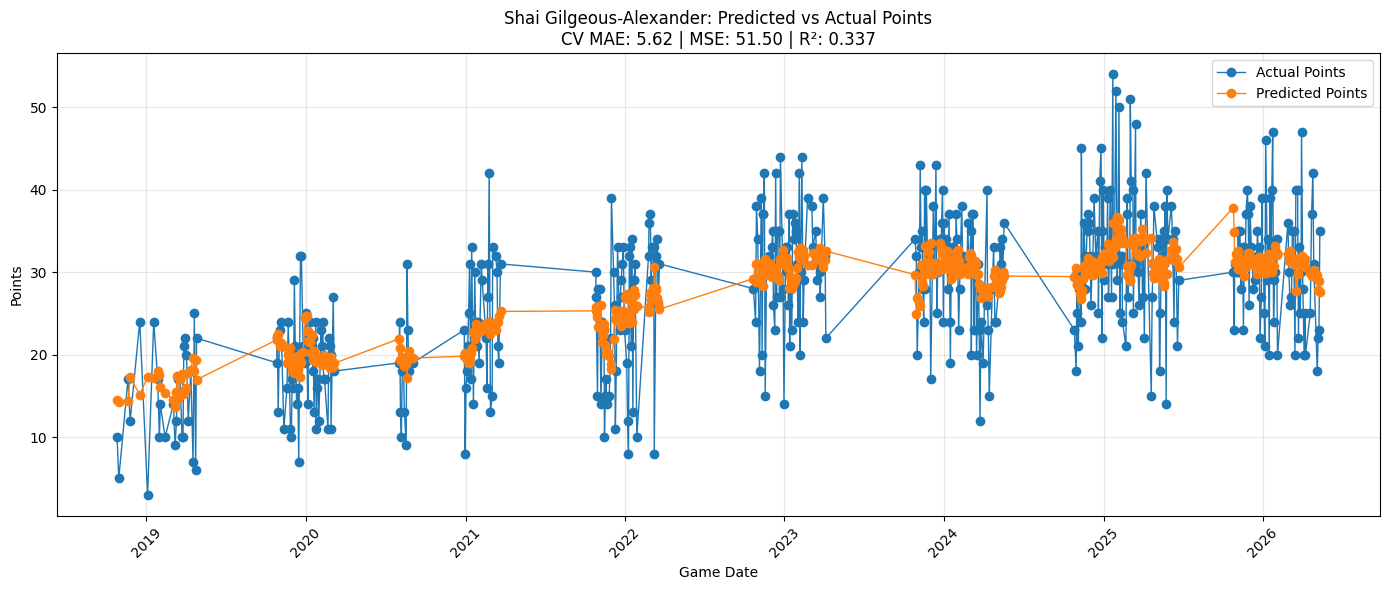

In [65]:

def plot_player_predicted_vs_actual(player_name, cv=8):
    player_df = create_player_model_df(player_name)

    feature_cols = [
        "Avg_PPG_last_6",
        "Avg_PPG_Matchup",
        "Avg_MIN_last_6",
        "Avg_FTA_last_6",
        "Avg_FGA_last_6",
        "Avg_FG3A_last_6",
        "HOME_AWAY_PPG"
    ]

    label_col = "PTS"

    model_cols = feature_cols + [label_col, "GAME_DATE"]
    player_df = player_df.dropna(subset=model_cols).copy()

    player_df = player_df.sort_values("GAME_DATE").reset_index(drop=True)

    X = player_df[feature_cols]
    y = player_df[label_col]

    model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0)
    )

    kfold = KFold(
        n_splits=cv,
        shuffle=True,
        random_state=42
    )

    player_df["PREDICTED_PTS"] = cross_val_predict(
        model,
        X,
        y,
        cv=kfold
    )

    mae = mean_absolute_error(player_df["PTS"], player_df["PREDICTED_PTS"])
    mse = mean_squared_error(player_df["PTS"], player_df["PREDICTED_PTS"])
    r2 = r2_score(player_df["PTS"], player_df["PREDICTED_PTS"])

    plt.figure(figsize=(14, 6))

    plt.plot(
        player_df["GAME_DATE"],
        player_df["PTS"],
        label="Actual Points",
        marker="o",
        linewidth=1
    )

    plt.plot(
        player_df["GAME_DATE"],
        player_df["PREDICTED_PTS"],
        label="Predicted Points",
        marker="o",
        linewidth=1
    )

    plt.title(
        f"{player_name}: Predicted vs Actual Points\n"
        f"CV MAE: {mae:.2f} | MSE: {mse:.2f} | R²: {r2:.3f}"
    )

    plt.xlabel("Game Date")
    plt.ylabel("Points")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return player_df[
        [
            "GAME_DATE",
            "PLAYER_NAME",
            "OPPONENT",
            "HOME",
            "PTS",
            "PREDICTED_PTS"
        ]
    ]


shai_predictions_df = plot_player_predicted_vs_actual("Shai Gilgeous-Alexander", cv=8)



# Model 2

Model 2, which was discussed in our project plan, will use a linear regression model to try and predict a player's point averages next season.


In [44]:
cols = [
    "MIN", "FGM", "FGA", "FG_PCT", "FG3M", "FG3A", "FG3_PCT",
    "FTM", "FTA", "FT_PCT", "OREB", "DREB", "REB", "AST",
    "STL", "BLK", "TOV", "PF", "TS_PCT", "EFG_PCT", "PPS",
    "3PAr", "2PAr", "FTAr", "PLUS_MINUS", "PTS"
]

season_stats_full = (
    all_years_game_stats
    .groupby(["PLAYER_NAME", "PLAYER_ID", "SEASON_START"])[cols]
    .mean()
    .reset_index()
)

season_games = (
    all_years_game_stats
    .groupby(["PLAYER_NAME", "PLAYER_ID", "SEASON_START"])
    .size()
    .reset_index(name="GAMES_PLAYED")
)

season_stats_full = season_stats_full.merge(
    season_games,
    on=["PLAYER_NAME", "PLAYER_ID", "SEASON_START"],
    how="left"
)

season_stats_full = season_stats_full.sort_values(
    ["PLAYER_ID", "SEASON_START"]
).reset_index(drop=True)



In [45]:
season_stats_full["PTS_next"] = (
    season_stats_full
    .groupby("PLAYER_ID")["PTS"]
    .shift(-1)
)

season_stats_full["SEASON_START_next"] = (
    season_stats_full
    .groupby("PLAYER_ID")["SEASON_START"]
    .shift(-1)
)


In [46]:
train_season_stats = season_stats_full.dropna(subset=["PTS_next"]).copy()


In [47]:
feature_cols = [
    "MIN",
    "FGA",
    "FG_PCT",
    "FG3A",
    "FG3_PCT",
    "FTA",
    "FT_PCT",
    "REB",
    "AST",
    "STL",
    "BLK",
    "TOV",
    "TS_PCT",
    "EFG_PCT",
    "PPS",
    "3PAr",
    "2PAr",
    "FTAr",
    "PLUS_MINUS",
    "PTS",
    "GAMES_PLAYED"
]

label_col = "PTS_next"

model_df = train_season_stats.dropna(subset=feature_cols + [label_col]).copy()

X = model_df[feature_cols]
y = model_df[label_col]


In [48]:

model = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.1, max_iter=10000)
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "R2": "r2"
}

cv_results = cross_validate(
    model,
    X,
    y,
    cv=8,
    scoring=scoring,
    return_train_score=True
)

results = pd.DataFrame({
    "Train MAE": -cv_results["train_MAE"],
    "Validation MAE": -cv_results["test_MAE"],
    "Train MSE": -cv_results["train_MSE"],
    "Validation MSE": -cv_results["test_MSE"],
    "Train R2": cv_results["train_R2"],
    "Validation R2": cv_results["test_R2"]
})

display(results)

print("Average Train MAE:", results["Train MAE"].mean())
print("Average Validation MAE:", results["Validation MAE"].mean())
print("Average Validation R2:", results["Validation R2"].mean())

,Train MAE,Validation MAE,Train MSE,Validation MSE,Train R2,Validation R2
0,2.443533,2.574245,9.907246,11.412333,0.730203,0.729357
1,2.438927,2.641629,9.774593,12.573515,0.747228,0.666841
2,2.473178,2.446687,10.270241,9.243922,0.737977,0.776252
3,2.479153,2.369404,10.304830,8.900589,0.737539,0.785379
4,2.463728,2.433849,10.137876,9.794098,0.752397,0.655265
5,2.467495,2.410449,10.175996,9.590985,0.741908,0.759043
6,2.473016,2.366175,10.217805,9.322280,0.752018,0.607238
7,2.440765,2.669631,9.934188,11.898582,0.752095,0.382643


Average Train MAE: 2.459974407242055
Average Validation MAE: 2.489008601070308
Average Validation R2: 0.6702523840931749


In [49]:
final_next_season_model = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.1, max_iter=10000)
)

final_next_season_model.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('lasso', Lasso(alpha=0.1, max_iter=10000))])

In [50]:
def predict_next_season_pts(
    player_name,
    model=final_next_season_model,
    feature_cols=feature_cols,
    df=season_stats_full
):
    player_df = df[
        df["PLAYER_NAME"].str.lower() == player_name.lower()
    ].sort_values("SEASON_START")

    if player_df.empty:
        raise ValueError(f"No seasons found for {player_name}")

    latest_row = player_df.iloc[[-1]].copy()

    missing_features = [col for col in feature_cols if col not in latest_row.columns]
    if missing_features:
        raise ValueError(f"Missing feature columns: {missing_features}")

    X_pred = latest_row[feature_cols]

    prediction = model.predict(X_pred)[0]

    return pd.DataFrame({
        "PLAYER_NAME": [latest_row["PLAYER_NAME"].iloc[0]],
        "PLAYER_ID": [latest_row["PLAYER_ID"].iloc[0]],
        "SEASON_START": [latest_row["SEASON_START"].iloc[0]],
        "Current season PPG": [latest_row["PTS"].iloc[0]],
        "Predicted next season PPG": [prediction],
        "Games played current season": [latest_row["GAMES_PLAYED"].iloc[0]]
    })

In [51]:
predict_next_season_pts("LeBron James")

,PLAYER_NAME,PLAYER_ID,SEASON_START,Current season PPG,Predicted next season PPG,Games played current season
0,lebron james,2544,2025,21.552239,21.32076,67


In [52]:


def plot_predicted_vs_actual_next_season_ppg(
    model,
    df,
    feature_cols,
    label_col="PTS_next",
    min_games=20,
    title="Predicted Next-Season PPG vs Actual Next-Season PPG"
):
    plot_df = df.dropna(subset=feature_cols + [label_col]).copy()

    if "GAMES_PLAYED" in plot_df.columns:
        plot_df = plot_df[plot_df["GAMES_PLAYED"] >= min_games].copy()

    X = plot_df[feature_cols]
    y_actual = plot_df[label_col]

    plot_df["Predicted_PTS_next"] = model.predict(X)

    y_pred = plot_df["Predicted_PTS_next"]

    mae = mean_absolute_error(y_actual, y_pred)
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_actual, y_pred)

    plt.figure(figsize=(8, 8))

    plt.scatter(y_actual, y_pred, alpha=0.5)

    min_val = min(y_actual.min(), y_pred.min())
    max_val = max(y_actual.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("Actual Next-Season PPG")
    plt.ylabel("Predicted Next-Season PPG")
    plt.title(title)

    plt.text(
        min_val,
        max_val,
        f"MAE = {mae:.2f}\nRMSE = {rmse:.2f}\nR² = {r2:.3f}",
        verticalalignment="top"
    )

    plt.show()

    return plot_df[
        [
            "PLAYER_NAME",
            "PLAYER_ID",
            "SEASON_START",
            "SEASON_START_next",
            "PTS",
            "PTS_next",
            "Predicted_PTS_next"
        ]
    ].sort_values("PTS_next", ascending=False)

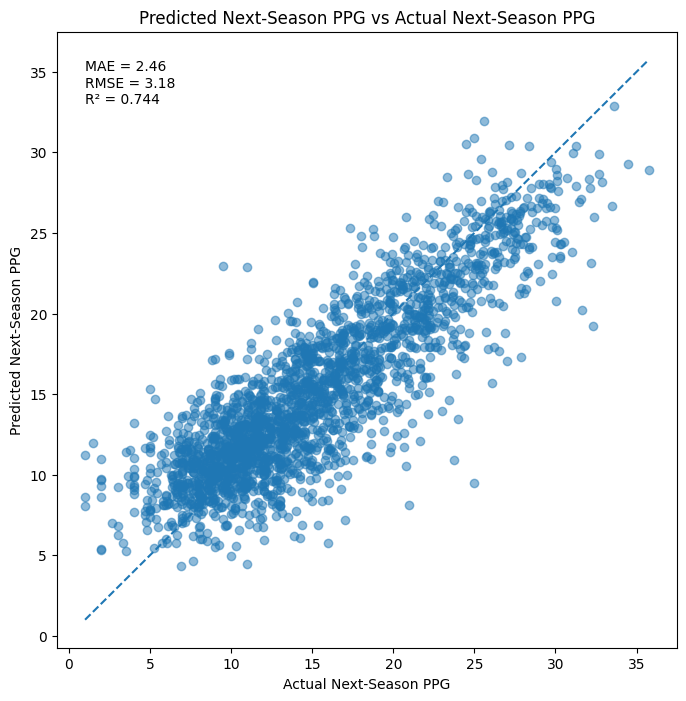

In [53]:
pred_vs_actual_df = plot_predicted_vs_actual_next_season_ppg(
    model=final_next_season_model,
    df=season_stats_full,
    feature_cols=feature_cols,
    min_games=0
)


In [54]:
# RUN WHEN UPDATING WEBSITE, *MEYER* MOVE TO PERSONAL COLABFOLDER

from google.colab import drive
drive.mount('/content/drive')
!jupyter nbconvert --to html \
"/content/drive/MyDrive/ColabNotebooks/CMPS3160_Project.ipynb" \
--output index.html \
--output-dir "/content/drive/MyDrive/ColabNotebooks/"


KeyboardInterrupt: 